# Ordinary Least Squares (OLS) Regression – Classroom Demo

## Goal
In this notebook we learn how **OLS works in Multiple Linear Regression** using a real dataset.

Dataset Download Link:
https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv

This dataset contains advertising budget spent on different media and the resulting sales.

Columns:
- TV
- Radio
- Newspaper
- Sales (target)

Business Question:
**How does advertising spending influence product sales?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Step 1 – Load Dataset

In [2]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 2 – Basic Data Understanding

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [4]:
df.drop("Unnamed: 0",axis=1,inplace=True)

## Step 3 – Visualization (WOW Moment)
Students immediately see the relationship between advertising spending and sales.

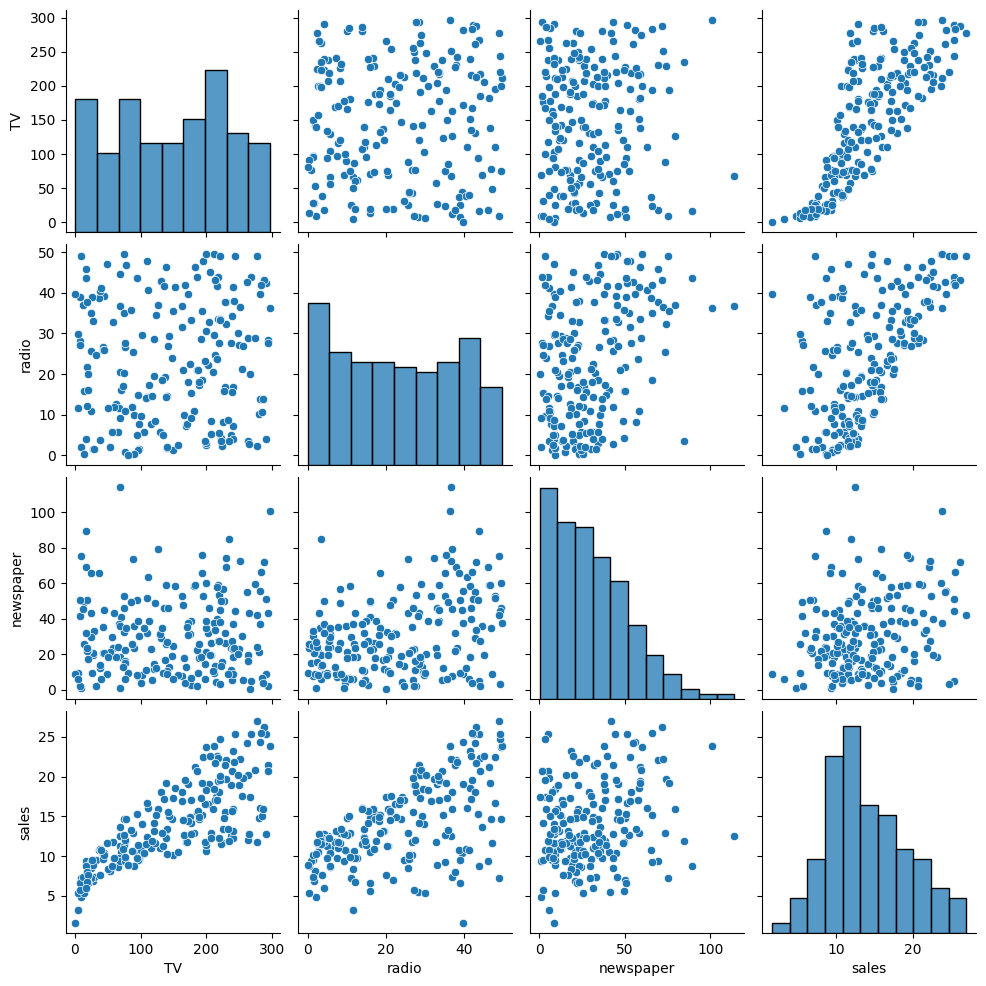

In [5]:
sns.pairplot(df)
plt.show()

## Step 4 – Define Features and Target

In [7]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [8]:
X = df[['TV','radio','newspaper']]
y = df['sales']

## Important Step – Add Constant
OLS requires an intercept term.

In [11]:
X = sm.add_constant(X)


## Step 5 – Build OLS Model

In [12]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.58e-96
Time:                        18:39:54   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [14]:
2.9389 * 0.312

0.9169368

# Understanding the OLS Summary Table

### R-squared
Explains how much variance in the target variable is explained by the model.

Example:
R² = 0.90 means **90% of sales variation is explained by advertising spending**.

### Adj R-squared
Adjusted for number of features.

### coef
Regression coefficient.
Shows how much target changes when feature increases by 1 unit.

### std err
Standard error of coefficient.

### t value
Used to test whether coefficient is significantly different from zero.

### P>|t|
If p-value < 0.05 → Feature is statistically significant.

### Confidence Interval
Range where coefficient is likely to fall.

### F-statistic
Tests whether overall regression model is significant.

# WOW MOMENT DEMO
Let's see how predictions change when TV budget increases.

In [15]:
new_data = pd.DataFrame({
    'const':[1,1,1],
    'TV':[50,100,200],
    'Radio':[20,20,20],
    'Newspaper':[30,30,30]
})

model.predict(new_data)

0     8.966597
1    11.254829
2    15.831294
dtype: float64

# Another WOW MOMENT – Remove a Feature
Let's see what happens if we remove Newspaper ads.

In [17]:
X2 = df[['TV','radio']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Fri, 08 May 2026   Prob (F-statistic):           4.83e-98
Time:                        18:43:54   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

In [20]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)
df = df.drop("Unnamed: 0",axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [21]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,const,6.848900
1,TV,1.004611
2,radio,1.144952
3,newspaper,1.145187


| VIF | Meaning                   |
| --- | ------------------------- |
| 1   | No correlation            |
| <5  | Acceptable                |
| >10 | Serious multicollinearity |


## Residual Analysis

Residual = Actual − Predicted

In [22]:
predictions = model.predict(X)

residuals = y - predictions

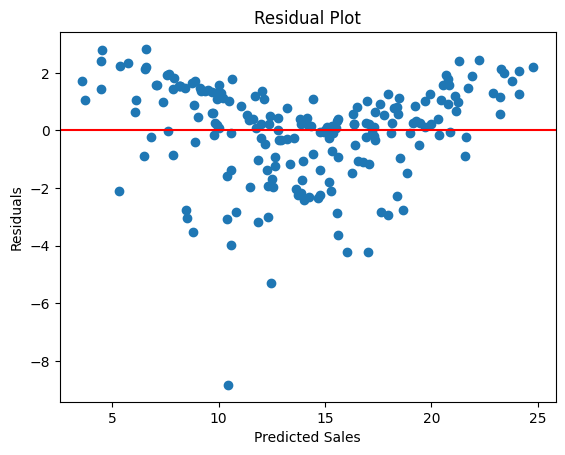

In [23]:
plt.scatter(predictions, residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Good model property:

Residuals should be **randomly scattered.**

## Heteroscedasticity Test

OLS assumes constant variance.

Test using **Breusch-Pagan test.**

In [24]:
test = het_breuschpagan(residuals, X)

labels = ["LM Statistic","LM-Test p-value","F Statistic","F-Test p-value"]

dict(zip(labels,test))

{'LM Statistic': np.float64(5.132872353285611),
 'LM-Test p-value': np.float64(0.16232215845412426),
 'F Statistic': np.float64(1.7209042102915884),
 'F-Test p-value': np.float64(0.16399908905607216)}

**`p-value > 0.05`**

Means variance is constant → assumption satisfied.

## How OLS Minimizes the Error

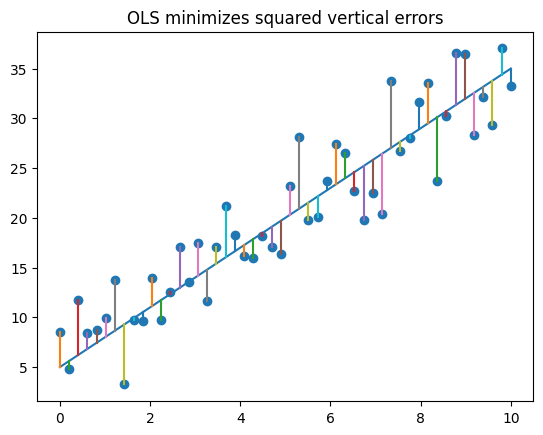

In [25]:
x = np.linspace(0,10,50)

y_true = 3*x + 5

noise = np.random.normal(0,4,50)

y = y_true + noise

plt.scatter(x,y)

line = 3*x + 5

plt.plot(x,line)

for i in range(len(x)):
    plt.plot([x[i],x[i]],[y[i],line[i]])

plt.title("OLS minimizes squared vertical errors")

plt.show()

The vertical lines represent **errors.**

OLS finds the **line that minimizes squared error.**

### Basic intution
"The model does not know the correct line.
It guesses a line, checks the error, and **keeps adjusting slope and intercept** until the error becomes minimal."

That adjustment process is **gradient descent searching for the OLS solution.**

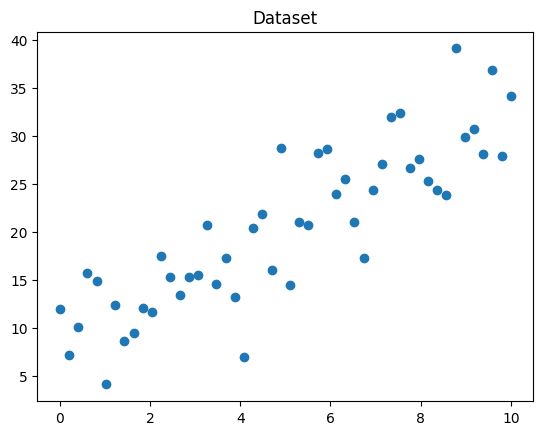

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# generate data
X = np.linspace(0,10,50)
y = 3*X + 5 + np.random.normal(0,4,50)

plt.scatter(X,y)
plt.title("Dataset")
plt.show()

### Initialize random line

In [27]:
# The algorithm starts with a random line.
slope = np.random.randn()
intercept = np.random.randn()

learning_rate = 0.01

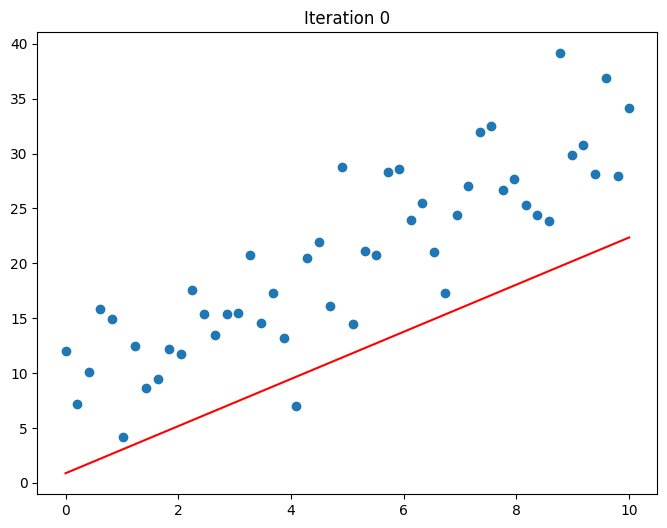

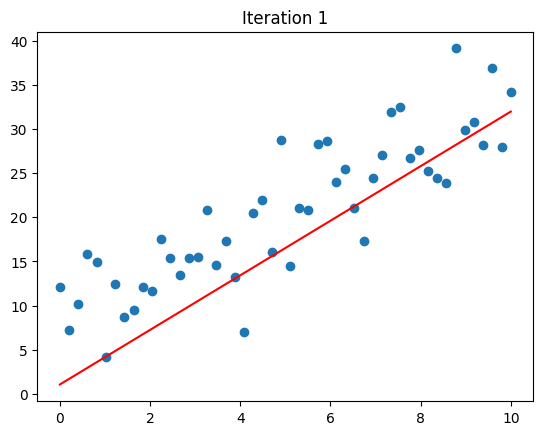

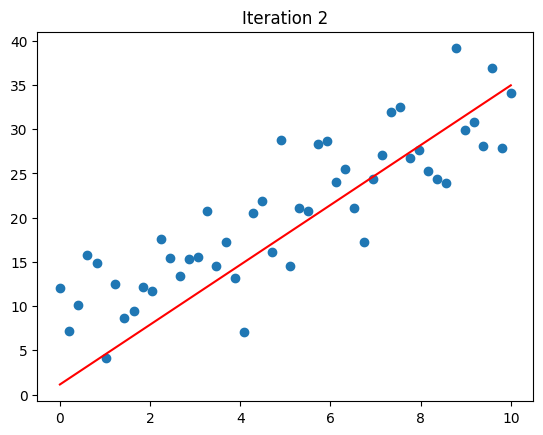

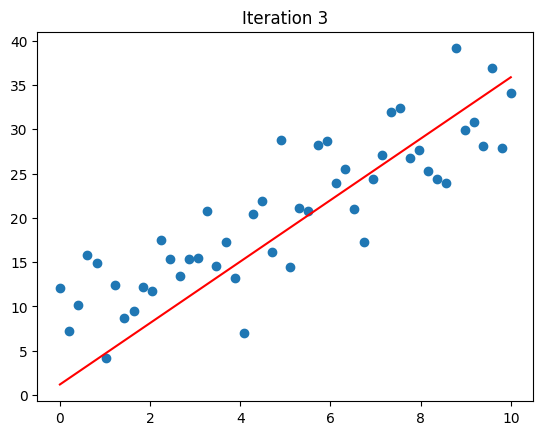

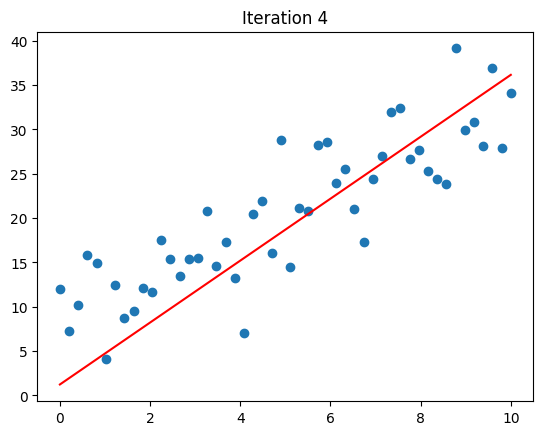

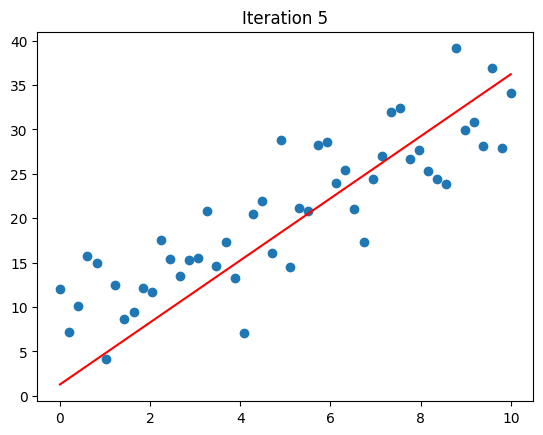

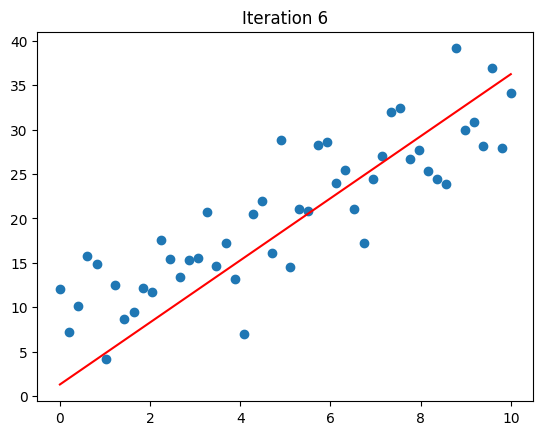

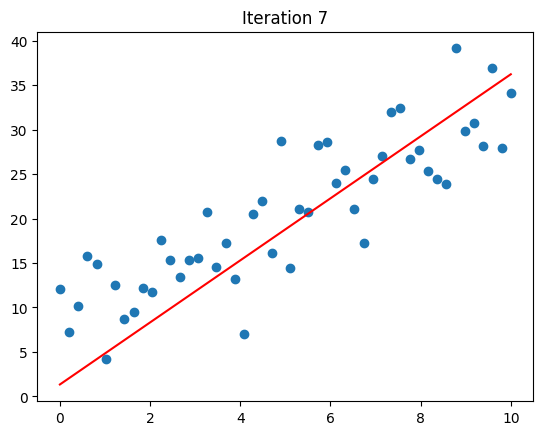

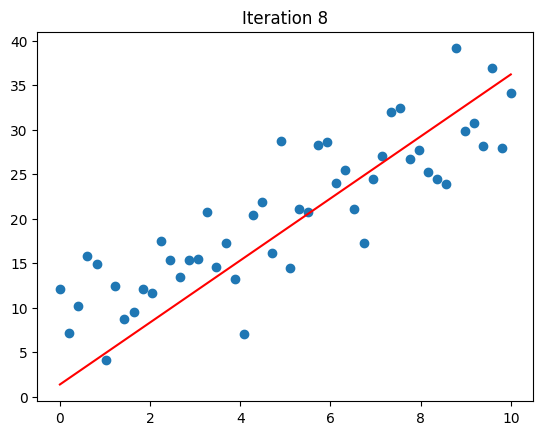

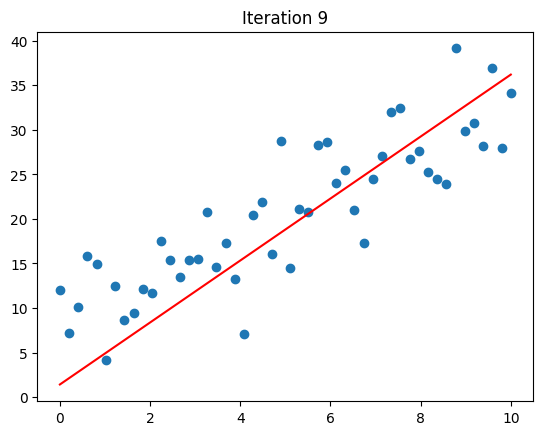

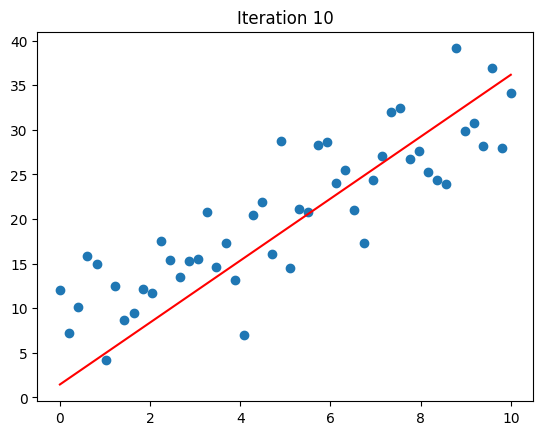

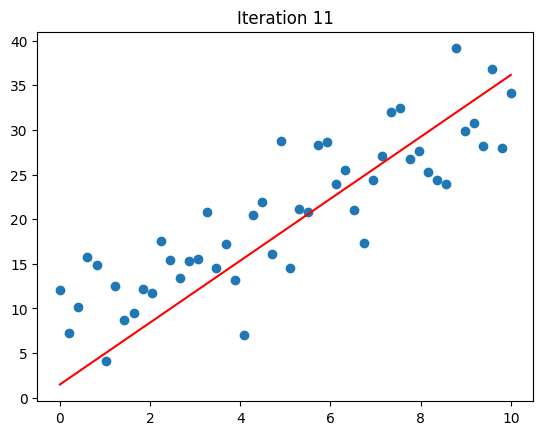

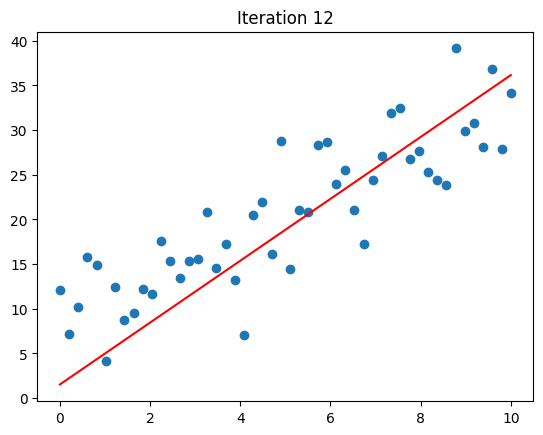

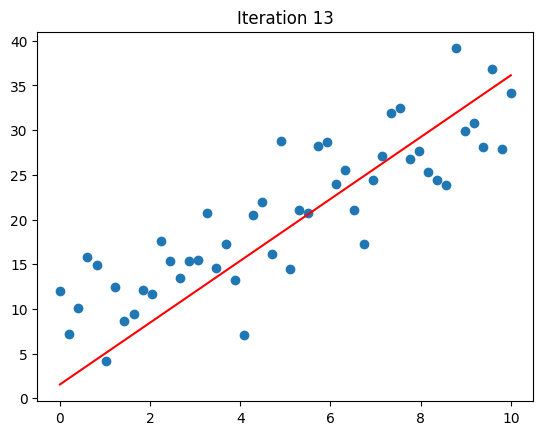

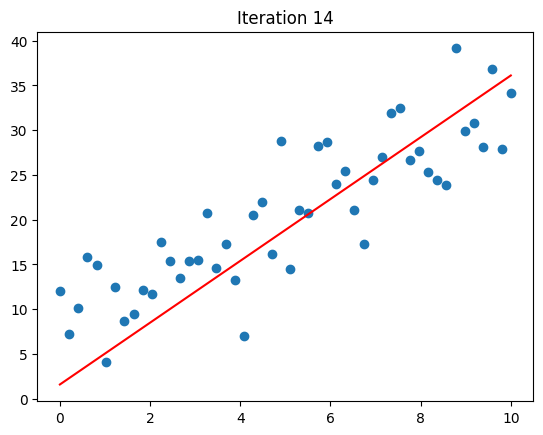

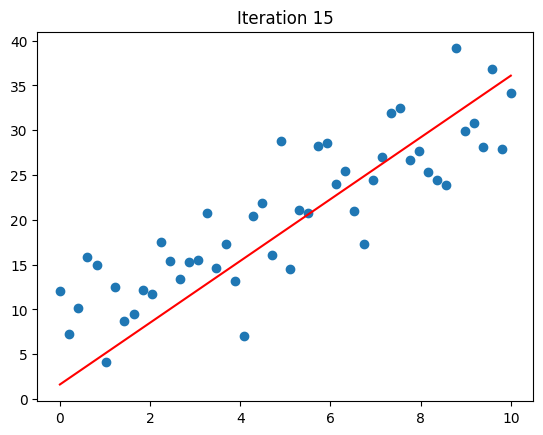

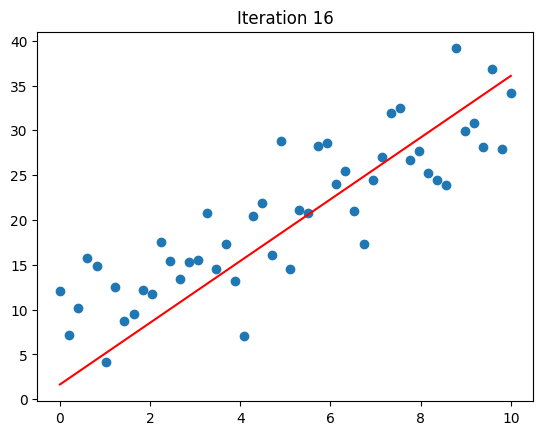

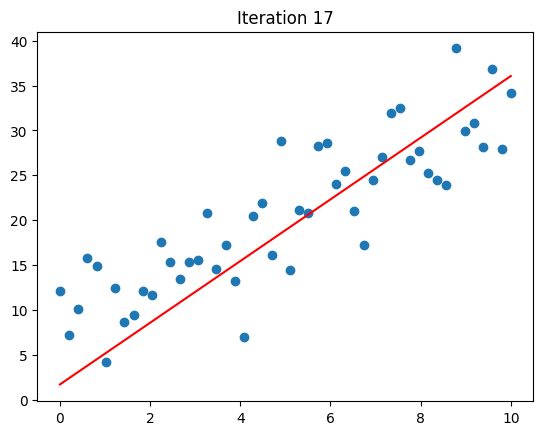

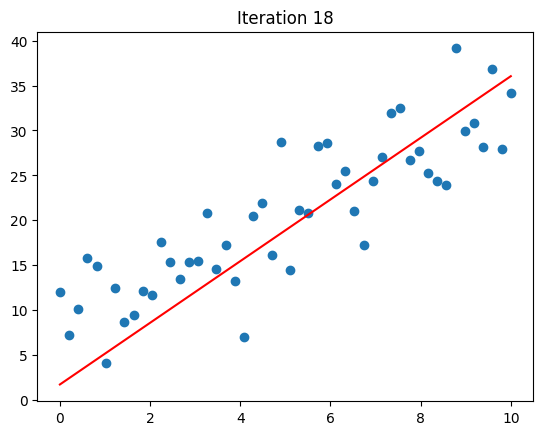

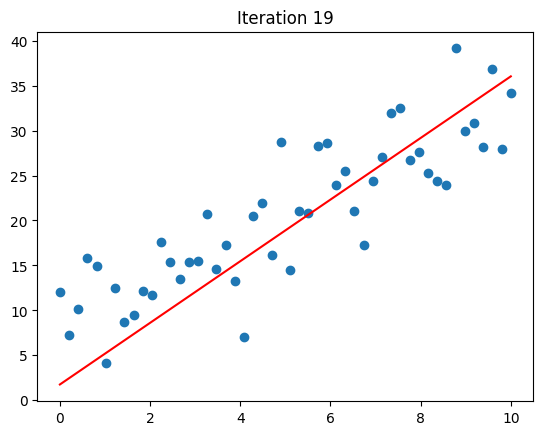

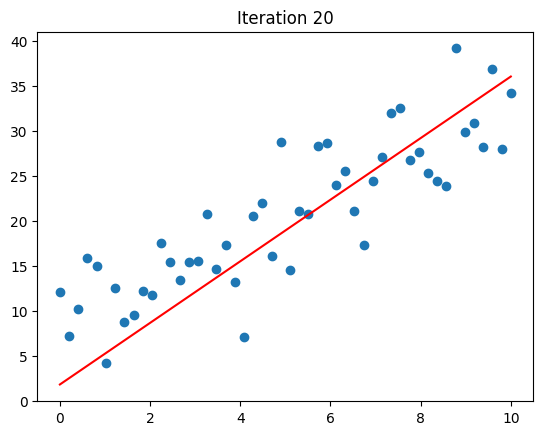

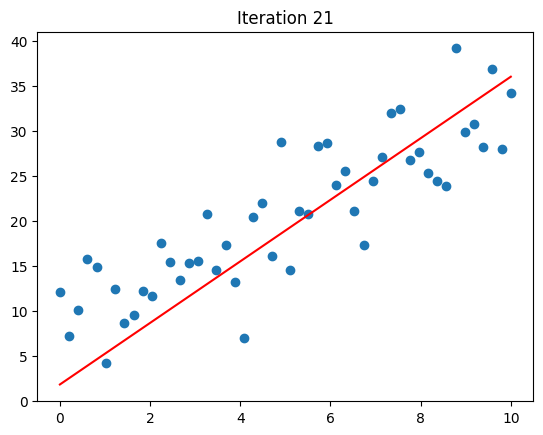

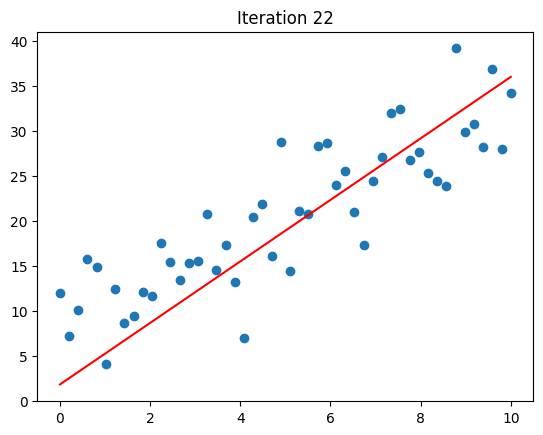

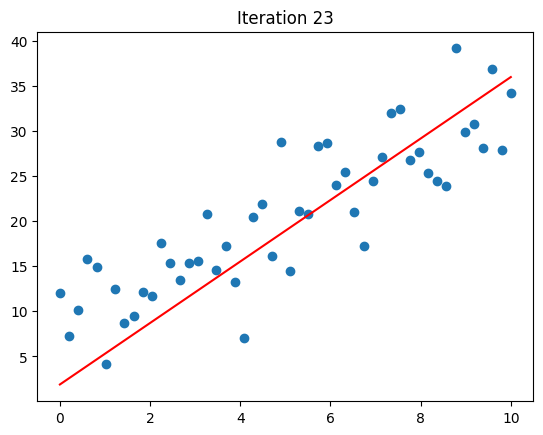

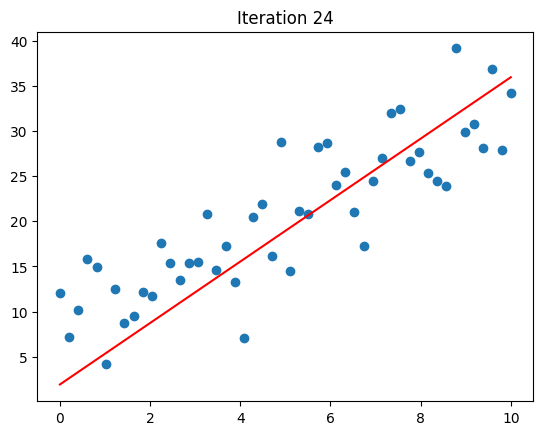

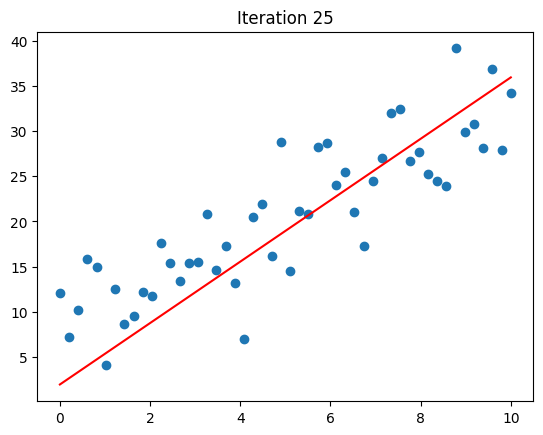

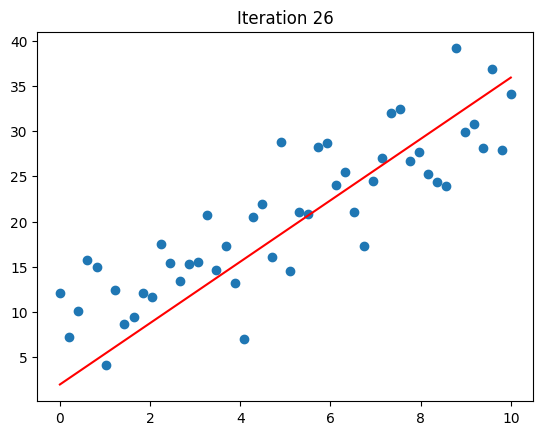

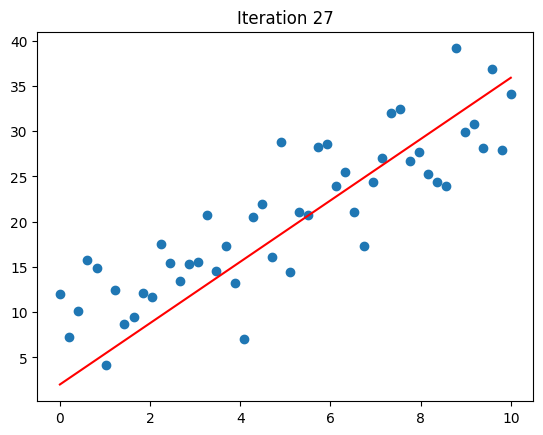

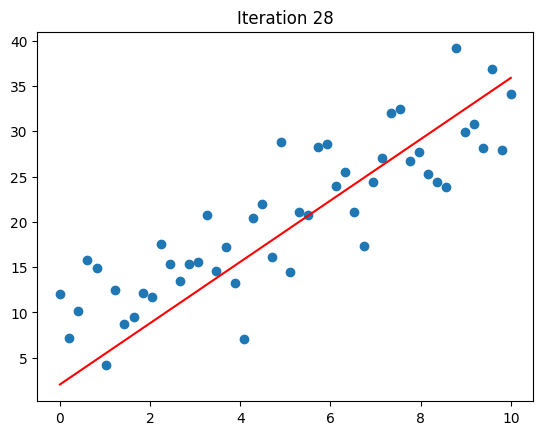

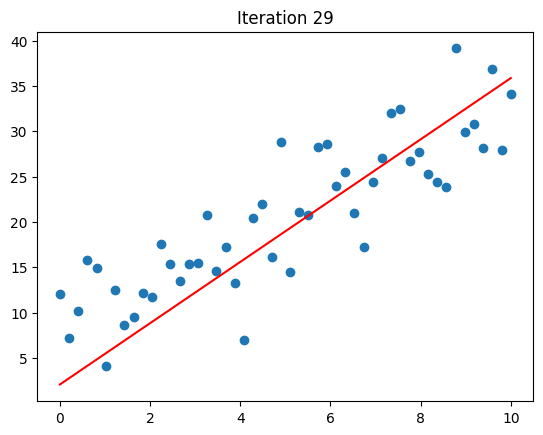

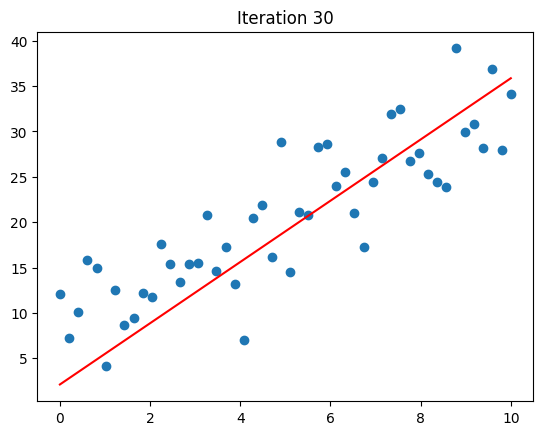

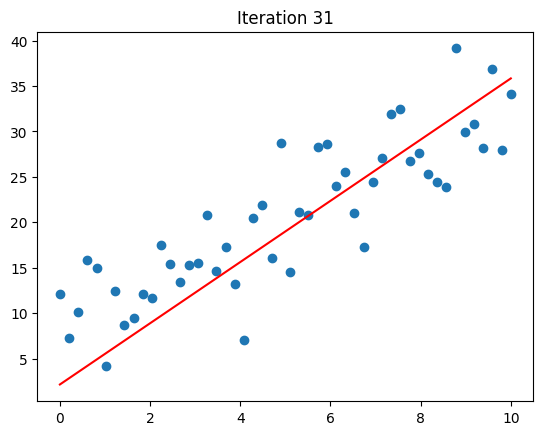

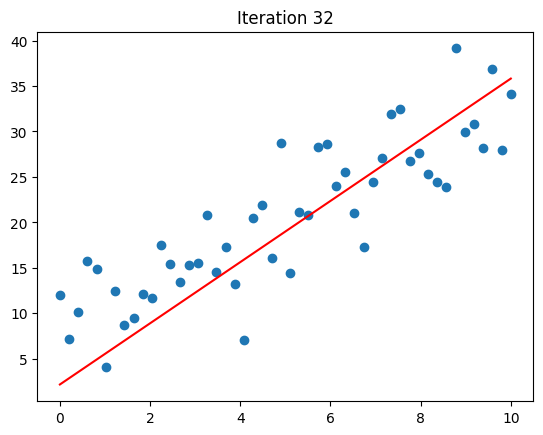

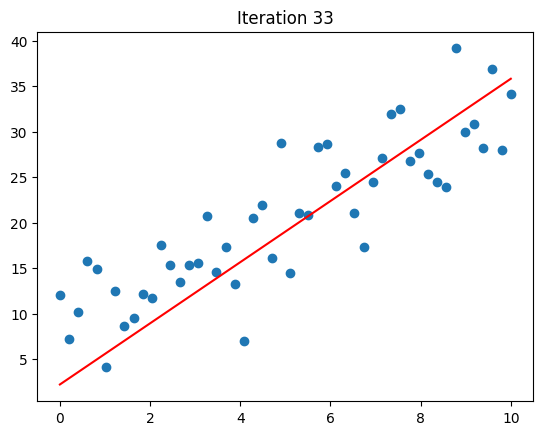

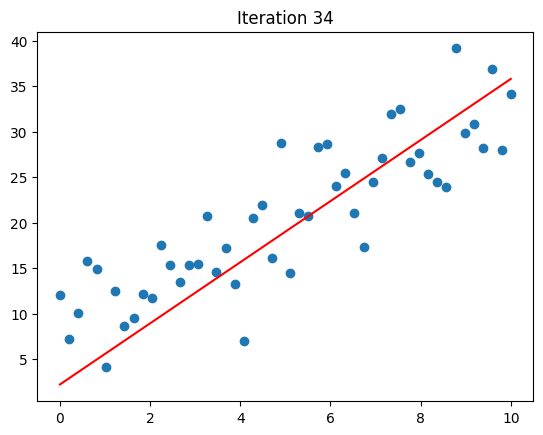

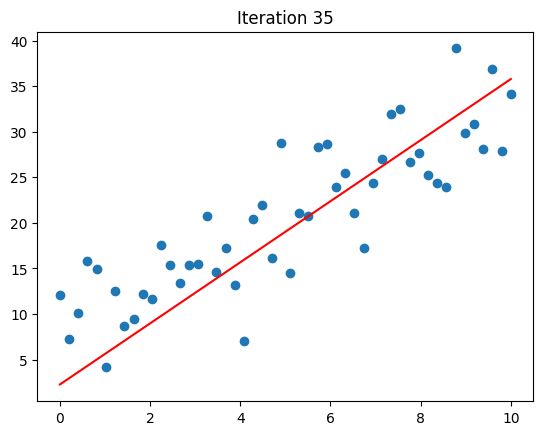

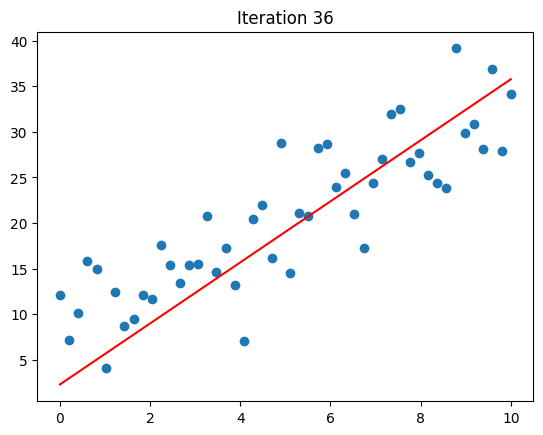

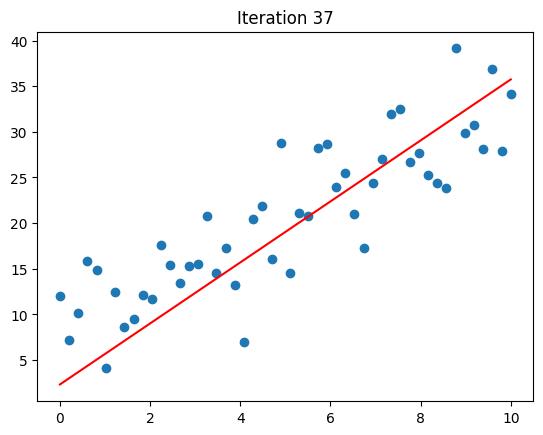

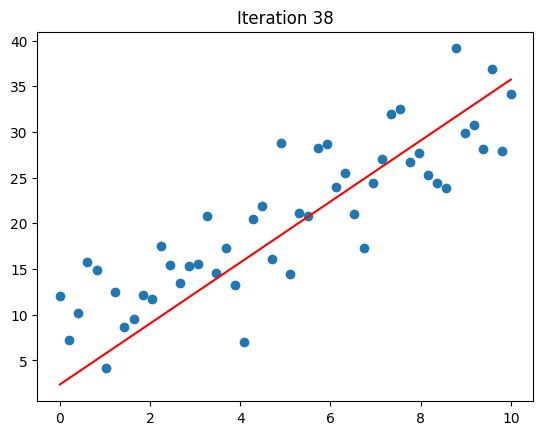

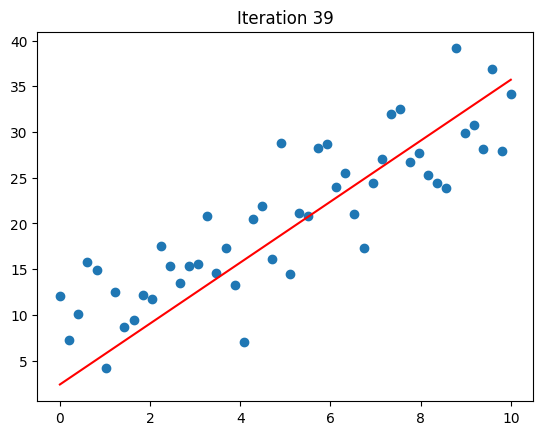

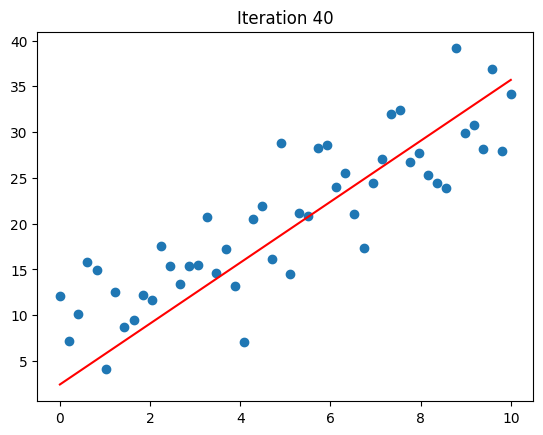

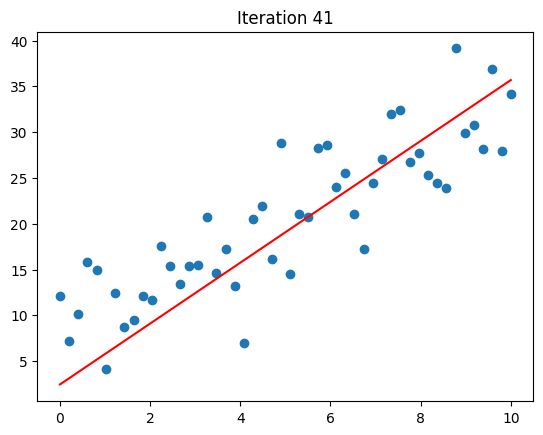

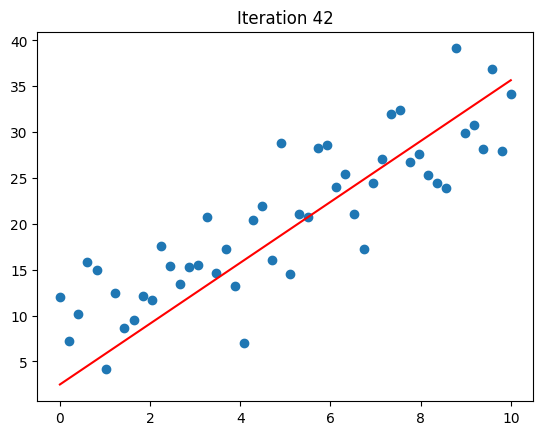

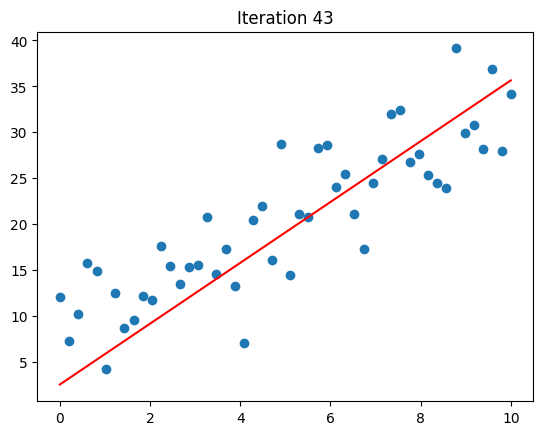

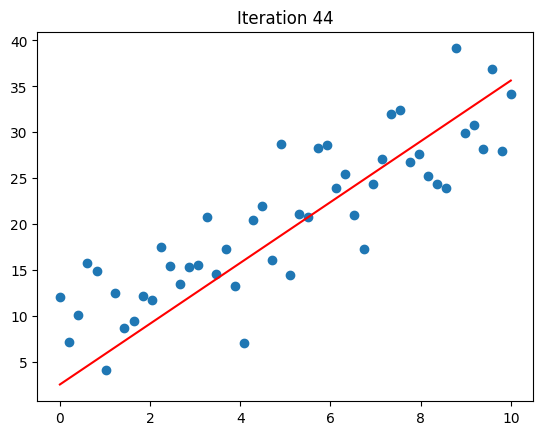

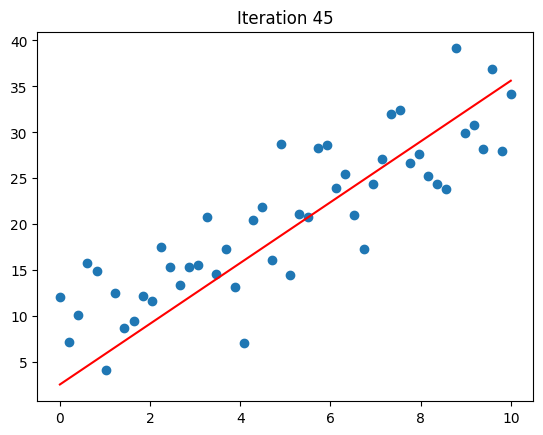

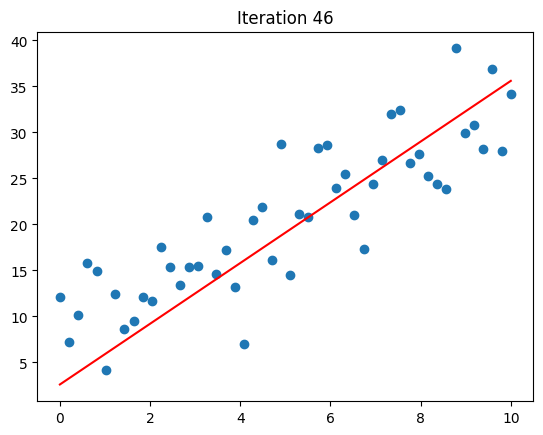

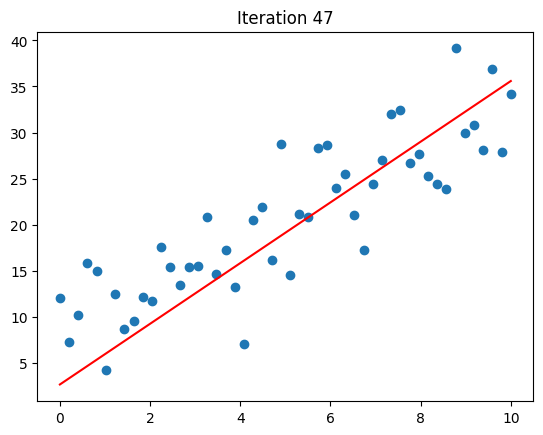

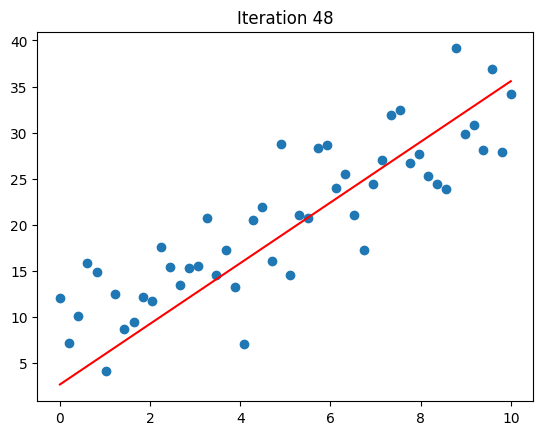

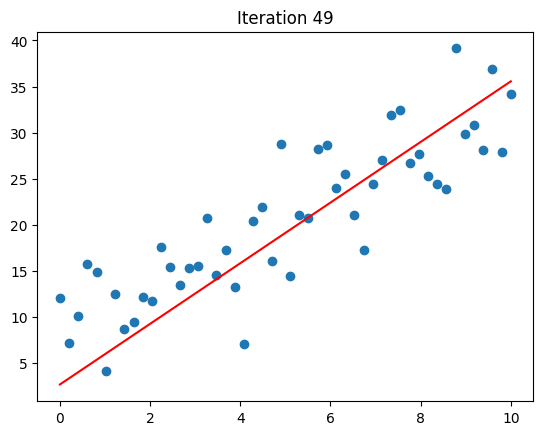

In [28]:
plt.figure(figsize=(8,6))

for i in range(50):

    y_pred = slope*X + intercept
    
    # compute gradients
    slope_grad = -2*np.mean(X*(y - y_pred))
    intercept_grad = -2*np.mean(y - y_pred)
    
    # update parameters
    slope -= learning_rate*slope_grad
    intercept -= learning_rate*intercept_grad
    
    # plot current line
    plt.cla()
    plt.scatter(X,y)
    plt.plot(X,slope*X + intercept,color='red')
    
    plt.title(f"Iteration {i}")
    plt.pause(0.2)

plt.show()

## Error Decreasing

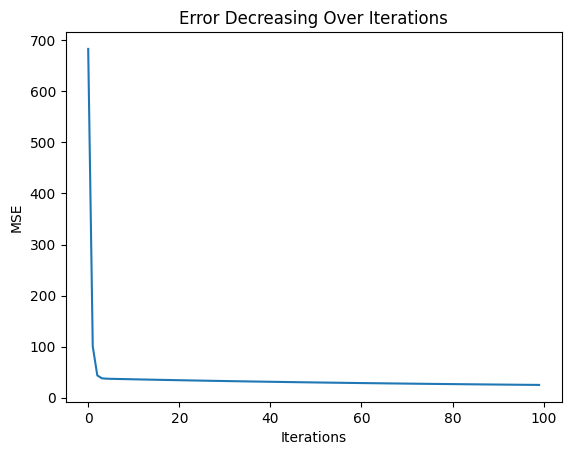

In [29]:
errors = []

slope = np.random.randn()
intercept = np.random.randn()

for i in range(100):
    
    y_pred = slope*X + intercept
    
    error = np.mean((y - y_pred)**2)
    errors.append(error)
    
    slope_grad = -2*np.mean(X*(y - y_pred))
    intercept_grad = -2*np.mean(y - y_pred)
    
    slope -= learning_rate*slope_grad
    intercept -= learning_rate*intercept_grad

plt.plot(errors)
plt.title("Error Decreasing Over Iterations")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

**error dropping continuously.**

This shows how **OLS minimizes squared error.**